# `Leakly` usage example
---

This example demonstrates how to use the `Leakly` package to perform a permutation test for checking potential leakage.

In this example,
 - We will synthesize data;
 - Run permutation tests with our exemplar machine learning pipeline;
 - Create a summary plot to interpret the results.


## Table of Contents
- [1. Synthesizing Data](#1-synthesizing-data)
- [2. Defining the Machine Learning Pipeline](#2-defining-the-machine-learning-pipeline)
- [3. Running Permutation Tests](#3-running-permutation-tests)
- [4. Visualizing Results](#4-visualizing-results)

In [ ]:
# install necessary packages
# !pip install numpy matplotlib scikit-learn scipy panadas matplotlib

## 1. Synthesizing Data
We will start by synthesizing a dataset that simulates a classification problem. We will use the `simulate_dataset` function from the `Leakly` package to create a dataset with a specified configuration.

In [13]:
# import libraries 
from leakly import SimulationConfig, simulate_dataset

simulated_data = simulate_dataset(
    SimulationConfig(
        n_samples=2000, # number of samples in the dataset
        n_features=1000, # number of features in the dataset
        n_covariates=3, # number of covariates in the dataset
        effect_fraction=0.1, # fraction of features that have an effect
        effect_size=0.1, # size of the effect for the informative features
        class_balance=0.1, # proportion of positive class
        random_state=42, # random seed for reproducibility
    )
)
X, y, covariates = \
    simulated_data.X, simulated_data.y, simulated_data.covariates


## 2. Defining the Machine Learning Pipeline

Next, we will define a machine learning pipeline. 

User may have their onw custom pipeline, as long as they has `pipeline(X, y, *covariates) -> test_score`, our package could handle. 

Here, we given an example pipelines that uses simple random forest model to classify the data.

In [4]:
from leakly import load_example_leakage_config, load_example_nonleakage_config
from leakly import print_config

leakage_config = load_example_leakage_config()
nonleakage_config = load_example_nonleakage_config()

# user could easily and modify the config
print_config(leakage_config)
# modify the config as you like
leakage_config["imputation"]["n_neighbors"] = 4
print_config(leakage_config)

pipeline:
- imputation
- normalization
- feature_selection
- data_split
- model
imputation:
  method: knn
  n_neighbors: 5
normalization:
  method: zscore
  with_mean: true
  with_std: true
data_split:
  method: train_test
  test_fraction: 0.2
  random_state: null
  stratify: true
feature_selection:
  method: LinearRegressionDAA
  alpha: 0.05
  minimum_effect_size: 0.0
  top_ranks: 10
  correction_method: fdr_bh
  selected_feature_names: null
model:
  model: random_forest
  problem_type: binary_classification
  metric: auc
  random_state: 42
  model_params:
    n_estimators: 100
    max_depth: 5
    min_samples_split: 2
    min_samples_leaf: 1
pipeline:
- imputation
- normalization
- feature_selection
- data_split
- model
imputation:
  method: knn
  n_neighbors: 4
normalization:
  method: zscore
  with_mean: true
  with_std: true
data_split:
  method: train_test
  test_fraction: 0.2
  random_state: null
  stratify: true
feature_selection:
  method: LinearRegressionDAA
  alpha: 0.05
  m

In [14]:
# remember you could put your own pipeline here, 
# as long as it could generate test score given X, y and covariates[optional].
from leakly import MLPipeline

leakage_pipeline = MLPipeline(X, y, covariates=covariates, config=leakage_config)
nonleakage_pipeline = MLPipeline(X, y, covariates=covariates, config=nonleakage_config)

In [15]:
# check test score (AUC in this case) for both pipelines
leakage_score = (leakage_pipeline.fit()).evaluate()
nonleakage_score = (nonleakage_pipeline.fit()).evaluate()

print(f"Leakage Pipeline Score: {leakage_score:.3f}")
print(f"Non-Leakage Pipeline Score: {nonleakage_score:.3f}")

Leakage Pipeline Score: 0.713
Non-Leakage Pipeline Score: 0.551


## 3. Running Permutation Tests

Once we have our data and machine learning pipeline defined, we can run permutation tests to evaluate the performance of our model and check for potential data leakage.

Since we have two pipelines (leakage and non-leakage), we will run permutation tests for both pipelines to compare their performance.

In [18]:
from leakly import permute_label
from tqdm.auto import tqdm

# let's set 1,000 permutations for statistical power, 
# you can adjust based on your computational resources and needs.
# it takes about 10 minutes to finish
N_PERMUTATIONS = 1000 

leakage_permuted_scores = []
nonleakage_permuted_scores = []

for i in tqdm(range(N_PERMUTATIONS), desc="Running permutations"):
    permuted_y = permute_label(y, random_state=None)  # Permute labels
    # define pipelines with permuted labels
    # user could change with their own pipeline
    leakage_pipeline_perm = MLPipeline(X, permuted_y, 
                                       covariates=covariates, 
                                       config=leakage_config)
    nonleakage_pipeline_perm = MLPipeline(X, permuted_y, 
                                          covariates=covariates, 
                                          config=nonleakage_config)

    # fit and get test scores for both pipelines with permuted labels
    leakage_score_perm = (leakage_pipeline_perm.fit()).evaluate()
    nonleakage_score_perm = (nonleakage_pipeline_perm.fit()).evaluate()

    leakage_permuted_scores.append(leakage_score_perm)
    nonleakage_permuted_scores.append(nonleakage_score_perm)


Running permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

## 4. Visualizing Results

Finally, we will use the `SummaryPlotter` class from the `Leakly` package to create a summary plot of the permutation test results. This plot will help us visualize the distribution of test scores under the null hypothesis and compare it to the observed test score.

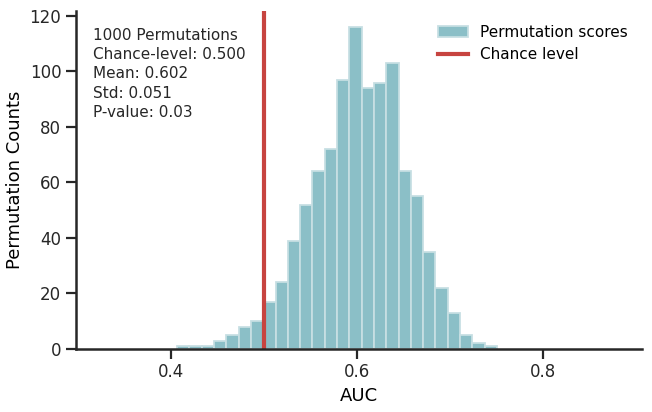

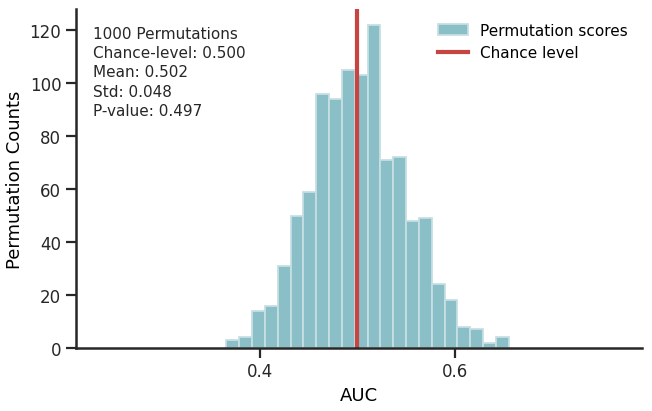

<Axes: xlabel='AUC', ylabel='Permutation Counts'>

In [19]:
from leakly import SummaryPlotter

leakage_plotter = SummaryPlotter(leakage_permuted_scores, chance_level=0.5)
leakage_plotter.plot()

nonlocal_plotter = SummaryPlotter(nonleakage_permuted_scores, chance_level=0.5)
nonlocal_plotter.plot()

We can observe that the leakage pipeline has a much higher AUC scores even no signal existed. 
However, the non-leakage pipeline got a chance-level AUC score, which is expected since there is no signal in the data.